# Plate Convergence and Spectral Analysis
Study of series convergence and wavenumber energy distribution.

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('..'))
from analysis.OptimizedPlate import OptimizedPlate

D, P, a, b, t = 1.0, -1.0, 1.0, 1.0, 0.01
xi, eta = 0.6, 0.6
res_x, res_y = 0.001, 0.001

## Convergence Loop

N = 300 | Error: 5.54e-04
N = 350 | Error: 3.54e-06
N = 400 | Error: 3.05e-06
N = 450 | Error: 2.62e-06
N = 500 | Error: 2.21e-06
N = 550 | Error: 1.99e-06
N = 600 | Error: 1.88e-06
N = 650 | Error: 1.79e-06
N = 700 | Error: 1.71e-06
N = 750 | Error: 1.58e-06
N = 800 | Error: 1.47e-06
N = 850 | Error: 1.36e-06
N = 900 | Error: 1.26e-06
N = 950 | Error: 1.15e-06
N = 1000 | Error: 1.05e-06
N = 1050 | Error: 9.48e-07
N = 1100 | Error: 8.38e-07
N = 1150 | Error: 7.41e-07
N = 1200 | Error: 6.47e-07
N = 1250 | Error: 5.59e-07
N = 1300 | Error: 4.75e-07
N = 1350 | Error: 4.04e-07
N = 1400 | Error: 3.25e-07
N = 1450 | Error: 2.58e-07
N = 1500 | Error: 2.00e-07
N = 1550 | Error: 1.46e-07
N = 1600 | Error: 9.68e-08


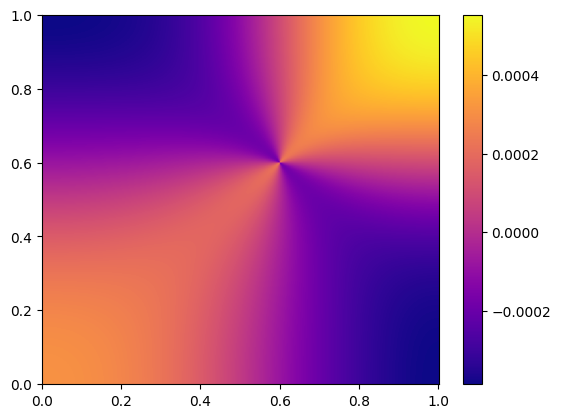

In [6]:
TOL, N = 1e-7, 300
p = OptimizedPlate(a, b, t, res_x, res_y, xi, eta, D, P, N)
res_old = np.zeros((len(p.x), len(p.y)))
max_diff = np.inf

while max_diff > TOL:
    p.N = int(N)
    res_new = p.strain_xy()
    diff_matrix = np.abs(res_new - res_old)
    
    X, Y = np.meshgrid(p.x, p.y, indexing='ij')
    mask = np.sqrt((X - xi)**2 + (Y - eta)**2) > 0.05
    max_diff = np.max(diff_matrix[mask])
    
    print(f'N = {N} | Error: {max_diff:.2e}')
    res_old = res_new.copy()
    if max_diff > TOL: N += 50

plt.pcolormesh(p.x, p.y, res_old.T, cmap='plasma')
plt.colorbar()
plt.show()